# Sharpe Ratio

---

## Importing libraries

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

---

## Cleaning data

In [2]:
tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', '^NSEBANK']
data = yf.download(tickers, period = "10y", auto_adjust=True)
data_dropped = data[~(data == 0).any(axis=1)].copy()
data_dropped = data_dropped[~data_dropped.isna().any(axis=1)].copy()
data_cleaned = data_dropped.copy()
data_cleaned['Volume'] = data_cleaned['Volume'].astype('float64').copy()

[*********************100%***********************]  3 of 3 completed


---

## Calculating sharpe ratio

In [3]:
data_close = data_cleaned['Close'].copy()
returns = data_close.pct_change().dropna()

# trading_days = len(data_close) # No need for this as if you are doing for multiple years too, then also the mean is just for daily and the trading_days is a scaling constant allowing for getting yearly data. 
trading_days = 252 # No need to make this with respect to the years of data pulled as the formula takes that into consideration. Mean gives mean of all days, so you get daily average.
risk_free_rate = 0.067

annual_return = returns.mean() * trading_days
annual_volatility = returns.std() * np.sqrt(trading_days)

sharpe = (annual_return - risk_free_rate) / annual_volatility

# Display Results
results = pd.DataFrame({
    'Annual Returns': annual_return,
    'Annualized Volatility': annual_volatility,
    'Sharpe Ratio': sharpe
})

print(results)

              Annual Returns  Annualized Volatility  Sharpe Ratio
Ticker                                                           
HDFCBANK.NS         0.243059               0.346995      0.507380
ICICIBANK.NS        0.379997               0.393676      0.795064
^NSEBANK            0.244449               0.313657      0.565741


---

## Plotting sharpe ratio

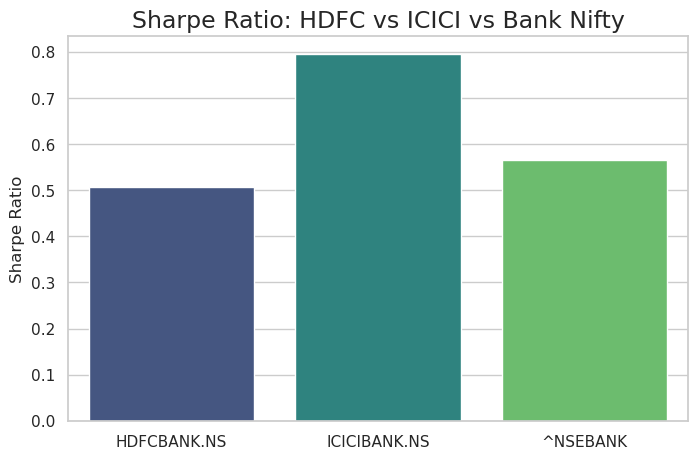

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.barplot(x=results.index, y=results['Sharpe Ratio'], hue=results.index, palette='viridis', legend=False)

plt.title('Sharpe Ratio: HDFC vs ICICI vs Bank Nifty', fontsize=17)
plt.ylabel('Sharpe Ratio')
plt.xlabel('')
plt.show()

---